In [2]:
import pandas as pd
import os

# Dosya yolunu proje yapına uygun şekilde güncelle
# notebooks klasöründen bir üste çıkıp data/raw içine bakıyoruz
file_path = "../data/raw/F1 Races 2020-2024.csv"

# Eğer dosya ana klasördeyse sadece "F1 Races 2020-2024.csv" yazabilirsin
# Ama düzenli olması için üstteki yol (path) daha iyidir.

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("✅ File loaded successfully!")
    print(f"Total rows: {len(df)}")
    display(df.head())
else:
    print(f"❌ Error: The file was not found at {os.path.abspath(file_path)}")
    print("Please make sure the CSV file is in the 'data/raw' folder.")

✅ File loaded successfully!
Total rows: 9839


,year,round,circuitId,date,rainy,Turns,Length,driverId,constructorId,grid,...,laps,statusId,Weighted_Top_3_Probability,Weighted_Top_3_Prob_Length,position_previous_race,nro_cond_escuderia,raceId,points,prom_points_10,Top 3 Finish
0,2000,1,1,2000-03-12,0,14,5.278,2,20,15,...,56,12,0.087719,0.090909,8.0,2,158,0.0,9.4,0
1,2000,1,1,2000-03-12,0,14,5.278,14,1,2,...,11,5,0.208333,0.222222,20.0,2,158,0.0,47.6,0
2,2000,1,1,2000-03-12,0,14,5.278,15,17,6,...,35,5,0.048387,0.083333,20.0,2,158,0.0,8.5,0
3,2000,1,1,2000-03-12,0,14,5.278,18,3,21,...,46,5,0.160494,0.235294,20.0,2,158,0.0,1.2,0
4,2000,1,1,2000-03-12,0,14,5.278,21,22,9,...,58,1,0.076923,0.100000,11.0,1,158,2.0,4.5,0


In [3]:
# Removing missing values as specified in the progress report
df_cleaned = df.dropna()
print(f"Data records after cleaning: {len(df_cleaned)}")

Data records after cleaning: 9839


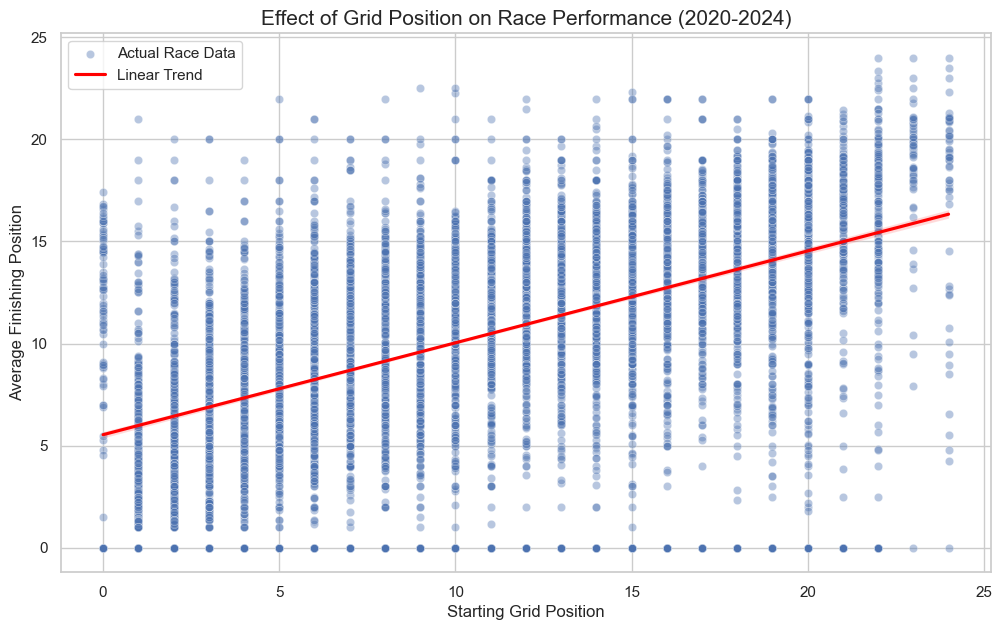

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Scatter plot for raw data distribution
sns.scatterplot(
    x="grid", 
    y="Driver Average Position (This Year till last race)", 
    data=df, 
    alpha=0.4, 
    label="Actual Race Data"
)

# Regression line to show the trend (the "heart" of your analysis)
sns.regplot(
    x="grid", 
    y="Driver Average Position (This Year till last race)", 
    data=df, 
    scatter=False, 
    color="red", 
    label="Linear Trend"
)

plt.title("Effect of Grid Position on Race Performance (2020-2024)", fontsize=15)
plt.xlabel("Starting Grid Position", fontsize=12)
plt.ylabel("Average Finishing Position", fontsize=12)
plt.legend()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Feature selection: Using 'grid' as the primary predictor [cite: 46]
X = df[['grid']] 
y = df['Driver Average Position (This Year till last race)']

# Splitting the data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train the Model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Make Predictions
y_pred = model_lr.predict(X_test)

# Evaluate the Performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Results (Linear Regression):")
print(f"Mean Absolute Error (MAE): {mae:.2f} positions")
print(f"R-squared Score: {r2:.2f}")

Model Results (Linear Regression):
Mean Absolute Error (MAE): 3.16 positions
R-squared Score: 0.29
